# Estimacion de Pose Humana: Detectando Keypoints

La estimacion de pose detecta puntos clave (keypoints) del cuerpo humano: cabeza, hombros, codos, muñecas, caderas, rodillas, tobillos, etc.

**Aplicaciones:**
- Analisis deportivo (tecnica de movimientos)
- Rehabilitacion y fisioterapia
- Control de accesos (deteccion de personas)
- Videojuegos y realidad aumentada
- Sistemas de vigilancia

En este notebook usaremos modelos de Hugging Face para detectar poses de manera sencilla.

## Configuracion e Imports

In [5]:
import torch
import transformers
from transformers import AutoProcessor, RTDetrForObjectDetection, VitPoseForPoseEstimation
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch version: {torch.__version__}, usando: {device}")
print(f"transformers version: {transformers.__version__}")

torch version: 2.6.0+cu124, usando: cuda
transformers version: 4.57.1


## Como funciona la deteccion de pose con VitPose

VitPose es un modelo basado en Vision Transformers para estimacion de pose. El proceso tiene 2 etapas:

**Etapa 1: Detectar personas** 
- Usamos RT-DETR para encontrar todas las personas en la imagen
- Obtenemos bounding boxes de cada persona

**Etapa 2: Detectar keypoints**
- Para cada persona detectada, VitPose encuentra 17 keypoints COCO:
  - 0-4: Nariz, ojos, orejas
  - 5-6: Hombros
  - 7-10: Codos y muñecas  
  - 11-12: Caderas
  - 13-16: Rodillas y tobillos

**Ventajas de VitPose:**
- ✅ Disponible en Transformers (facil de usar)
- ✅ Muy preciso gracias a Vision Transformers
- ✅ Arquitectura MOE (Mixture of Experts) para diferentes datasets

In [6]:
# Cargar modelos para deteccion de personas y pose
print("Cargando RT-DETR para detectar personas...")
person_processor = AutoProcessor.from_pretrained("PekingU/rtdetr_r50vd_coco_o365")
person_model = RTDetrForObjectDetection.from_pretrained("PekingU/rtdetr_r50vd_coco_o365").to(device)

print("Cargando VitPose para detectar keypoints...")
pose_processor = AutoProcessor.from_pretrained("usyd-community/vitpose-plus-base")
pose_model = VitPoseForPoseEstimation.from_pretrained("usyd-community/vitpose-plus-base").to(device)

print("\nModelos cargados correctamente!")

Cargando RT-DETR para detectar personas...
Cargando VitPose para detectar keypoints...
Cargando VitPose para detectar keypoints...

Modelos cargados correctamente!

Modelos cargados correctamente!


## Carga del Modelo YOLOv8-Pose

YOLOv8 tiene diferentes tamaños: n (nano), s (small), m (medium), l (large), x (extra large). Usaremos `yolov8m-pose.pt` que da buen balance entre velocidad y precision.

El modelo detecta **17 keypoints** del formato COCO:
0. Nariz
1. Ojo izquierdo
2. Ojo derecho
3. Oreja izquierda
4. Oreja derecha
5. Hombro izquierdo
6. Hombro derecho
7. Codo izquierdo
8. Codo derecho
9. Muñeca izquierda
10. Muñeca derecha
11. Cadera izquierda
12. Cadera derecha
13. Rodilla izquierda
14. Rodilla derecha
15. Tobillo izquierdo
16. Tobillo derecho

In [7]:
## Carga de Imagen de Ejemplo

Imagen cargada


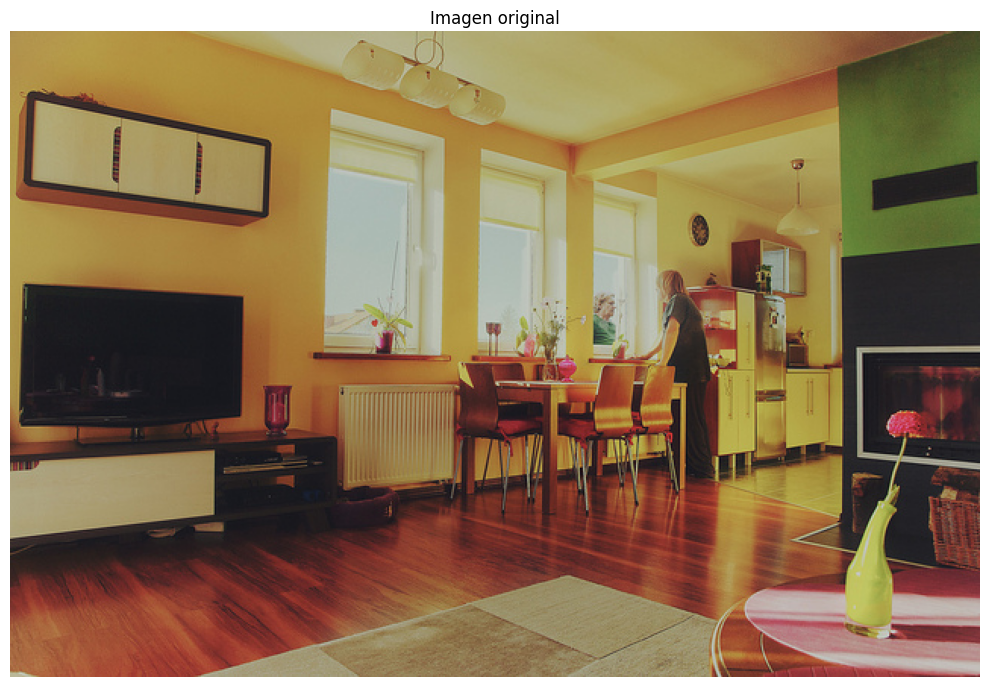

In [8]:
# Cargar imagen desde COCO dataset
url = "http://images.cocodataset.org/val2017/000000000139.jpg"
image = Image.open(requests.get(url, stream=True).raw)

print("Imagen cargada")
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.title("Imagen original")
plt.axis("off")
plt.tight_layout()
plt.show()

## Paso 1: Detectar Personas en la Imagen

Primero usamos RT-DETR para encontrar todas las personas (clase 0 en COCO).

In [9]:
# Detectar personas con RT-DETR
inputs = person_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = person_model(**inputs)

# Post-procesar detecciones (solo personas con confianza > 0.3)
results = person_processor.post_process_object_detection(
    outputs, target_sizes=torch.tensor([(image.height, image.width)]), threshold=0.3
)
result = results[0]

# Filtrar solo clase 0 (persona en COCO)
person_boxes = result["boxes"][result["labels"] == 0]
person_boxes = person_boxes.cpu().numpy()

# Convertir de formato VOC (x1, y1, x2, y2) a COCO (x1, y1, w, h)
person_boxes[:, 2] = person_boxes[:, 2] - person_boxes[:, 0]
person_boxes[:, 3] = person_boxes[:, 3] - person_boxes[:, 1]

print(f"Detectadas {len(person_boxes)} personas\n")
for i, box in enumerate(person_boxes):
    x, y, w, h = box
    print(f"  Persona {i+1}: x={x:.0f}, y={y:.0f}, w={w:.0f}, h={h:.0f}")

Detectadas 2 personas

  Persona 1: x=417, y=157, w=48, h=139
  Persona 2: x=384, y=172, w=17, h=35


## Paso 2: Detectar Keypoints con VitPose

Ahora usamos VitPose para encontrar los 17 keypoints de cada persona detectada.

In [10]:
# Detectar keypoints con VitPose
inputs_pose = pose_processor(image, boxes=[person_boxes], return_tensors="pt").to(device)

# VitPose es MOE (Mixture of Experts), necesita especificar dataset (0 = COCO)
inputs_pose["dataset_index"] = torch.tensor([0], device=device)

with torch.no_grad():
    outputs_pose = pose_model(**inputs_pose)

# Post-procesar keypoints (threshold 0.3)
pose_results = pose_processor.post_process_pose_estimation(outputs_pose, boxes=[person_boxes], threshold=0.3)
image_pose_result = pose_results[0]

# Mostrar keypoints detectados
for i, person_pose in enumerate(image_pose_result):
    print(f"\nPersona {i+1}:")
    print(f"  Keypoints detectados: {len(person_pose['keypoints'])}")
    
    for keypoint, label, score in zip(person_pose["keypoints"], person_pose["labels"], person_pose["scores"]):
        keypoint_name = pose_model.config.id2label[label.item()]
        x, y = keypoint
        print(f"    - {keypoint_name}: x={x.item():.1f}, y={y.item():.1f}, score={score.item():.2f}")


Persona 1:
  Keypoints detectados: 17
    - Nose: x=428.8, y=171.5, score=0.92
    - L_Eye: x=429.3, y=168.3, score=0.92
    - R_Eye: x=428.8, y=168.5, score=0.82
    - L_Ear: x=434.6, y=166.5, score=0.90
    - R_Ear: x=440.1, y=165.8, score=0.80
    - L_Shoulder: x=440.7, y=177.0, score=0.96
    - R_Shoulder: x=444.1, y=177.5, score=0.68
    - L_Elbow: x=436.3, y=197.1, score=0.91
    - R_Elbow: x=432.3, y=201.2, score=0.79
    - L_Wrist: x=429.9, y=217.9, score=0.84
    - R_Wrist: x=421.1, y=212.7, score=0.90
    - L_Hip: x=446.2, y=223.9, score=0.74
    - R_Hip: x=449.3, y=223.4, score=0.65
    - L_Knee: x=443.7, y=255.7, score=0.76
    - R_Knee: x=450.7, y=255.2, score=0.73
    - L_Ankle: x=452.1, y=287.3, score=0.66
    - R_Ankle: x=456.0, y=286.0, score=0.72

Persona 2:
  Keypoints detectados: 6
    - Nose: x=398.2, y=181.6, score=0.88
    - L_Eye: x=398.7, y=179.8, score=0.87
    - R_Eye: x=396.1, y=179.4, score=0.87
    - R_Ear: x=388.9, y=180.4, score=0.87
    - L_Shoulder: x

## Visualizar Keypoints y Skeleton

Vamos a dibujar los keypoints y las conexiones del esqueleto humano.

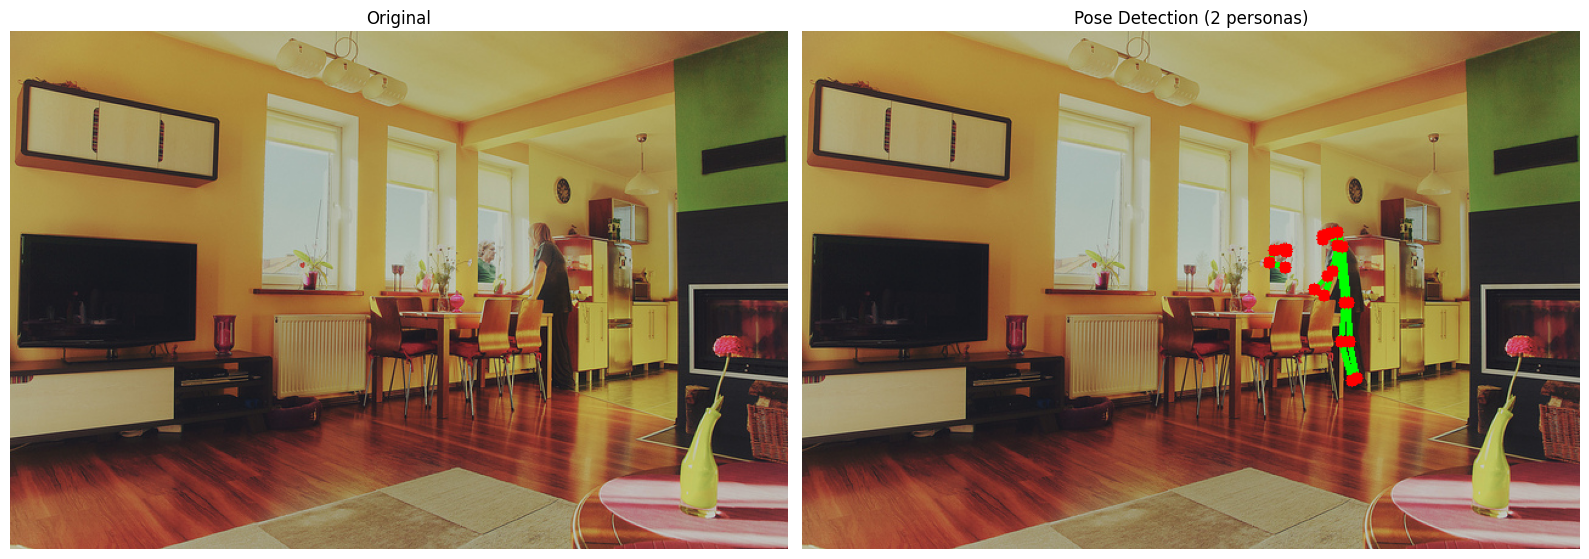

In [11]:
def draw_pose(image, pose_results, min_score=0.3):
    """Dibuja keypoints y skeleton sobre la imagen"""
    
    img_array = np.array(image).copy()
    
    # Definir conexiones del skeleton (formato COCO)
    skeleton = [
        (15, 13), (13, 11), (16, 14), (14, 12), (11, 12),  # Piernas
        (5, 11), (6, 12),  # Torso
        (5, 6), (5, 7), (6, 8), (7, 9), (8, 10),  # Brazos
        (0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6)  # Cabeza
    ]
    
    for person_pose in pose_results:
        # Crear diccionario de keypoints por ID
        kpts_dict = {}
        for keypoint, label, score in zip(person_pose["keypoints"], person_pose["labels"], person_pose["scores"]):
            if score.item() > min_score:
                kpts_dict[label.item()] = (int(keypoint[0].item()), int(keypoint[1].item()))
        
        # Dibujar lineas del skeleton
        for pt1_idx, pt2_idx in skeleton:
            if pt1_idx in kpts_dict and pt2_idx in kpts_dict:
                pt1 = kpts_dict[pt1_idx]
                pt2 = kpts_dict[pt2_idx]
                cv2.line(img_array, pt1, pt2, (0, 255, 0), 3)
        
        # Dibujar keypoints
        for kpt in kpts_dict.values():
            cv2.circle(img_array, kpt, 5, (255, 0, 0), -1)
    
    return img_array

# Visualizar
img_with_pose = draw_pose(image, image_pose_result)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_with_pose)
axes[1].set_title(f"Pose Detection ({len(image_pose_result)} personas)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Funcion Completa: Deteccion de Pose End-to-End

Juntamos todo en una funcion sencilla que hace todo el proceso automaticamente.

Detectadas 2 personas


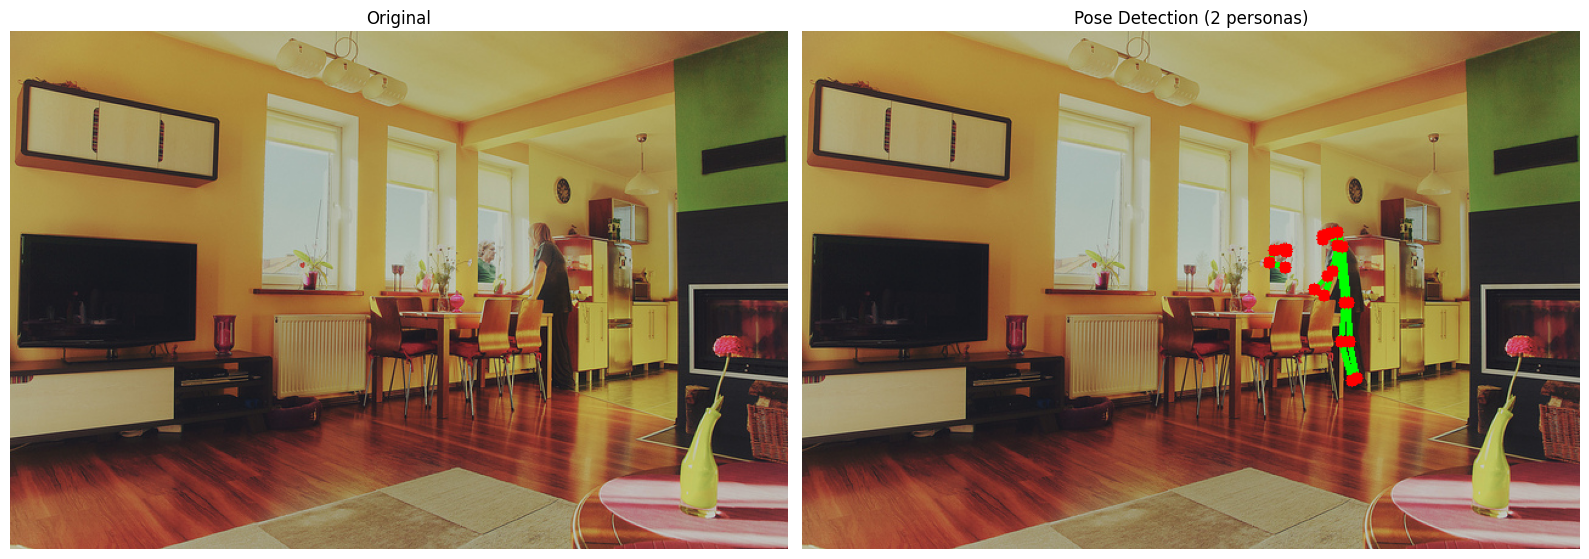

In [12]:
def detect_pose_complete(image, person_threshold=0.3, keypoint_threshold=0.3):
    """Deteccion completa de pose: personas + keypoints + visualizacion"""
    
    # Paso 1: Detectar personas
    inputs = person_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = person_model(**inputs)
    
    results = person_processor.post_process_object_detection(
        outputs, target_sizes=torch.tensor([(image.height, image.width)]), threshold=person_threshold
    )
    result = results[0]
    
    person_boxes = result["boxes"][result["labels"] == 0].cpu().numpy()
    person_boxes[:, 2] = person_boxes[:, 2] - person_boxes[:, 0]
    person_boxes[:, 3] = person_boxes[:, 3] - person_boxes[:, 1]
    
    if len(person_boxes) == 0:
        print("No se detectaron personas")
        return None
    
    print(f"Detectadas {len(person_boxes)} personas")
    
    # Paso 2: Detectar keypoints
    inputs_pose = pose_processor(image, boxes=[person_boxes], return_tensors="pt").to(device)
    inputs_pose["dataset_index"] = torch.tensor([0], device=device)
    
    with torch.no_grad():
        outputs_pose = pose_model(**inputs_pose)
    
    pose_results = pose_processor.post_process_pose_estimation(
        outputs_pose, boxes=[person_boxes], threshold=keypoint_threshold
    )
    
    # Paso 3: Visualizar
    img_with_pose = draw_pose(image, pose_results[0], min_score=keypoint_threshold)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(img_with_pose)
    axes[1].set_title(f"Pose Detection ({len(person_boxes)} personas)")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return pose_results[0]

# Probar con la imagen cargada
results = detect_pose_complete(image)

## Calcular Angulos de Articulaciones

Podemos usar los keypoints para medir angulos, util para analisis deportivo o fisioterapia.

In [13]:
def calculate_angle(p1, p2, p3):
    """Calcula angulo entre tres puntos (p2 es el vertice)"""
    a = np.array(p1)
    b = np.array(p2)
    c = np.array(p3)
    
    ba = a - b
    bc = c - b
    
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
    
    return angle

def analyze_angles(pose_results, min_score=0.5):
    """Analiza angulos de las articulaciones principales"""
    
    # Mapeo de nombres de keypoints a IDs
    keypoint_map = {
        'nose': 0, 'left_eye': 1, 'right_eye': 2, 'left_ear': 3, 'right_ear': 4,
        'left_shoulder': 5, 'right_shoulder': 6, 'left_elbow': 7, 'right_elbow': 8,
        'left_wrist': 9, 'right_wrist': 10, 'left_hip': 11, 'right_hip': 12,
        'left_knee': 13, 'right_knee': 14, 'left_ankle': 15, 'right_ankle': 16
    }
    
    for i, person_pose in enumerate(pose_results):
        print(f"\nPersona {i+1} - Analisis de angulos:\n")
        
        # Crear diccionario de keypoints
        kpts = {}
        for keypoint, label, score in zip(person_pose["keypoints"], person_pose["labels"], person_pose["scores"]):
            if score.item() > min_score:
                kpts[label.item()] = (keypoint[0].item(), keypoint[1].item())
        
        # Codo derecho (hombro-codo-muñeca)
        if 6 in kpts and 8 in kpts and 10 in kpts:
            angle = calculate_angle(kpts[6], kpts[8], kpts[10])
            print(f"  Codo derecho: {angle:.1f}°")
        
        # Codo izquierdo
        if 5 in kpts and 7 in kpts and 9 in kpts:
            angle = calculate_angle(kpts[5], kpts[7], kpts[9])
            print(f"  Codo izquierdo: {angle:.1f}°")
        
        # Rodilla derecha (cadera-rodilla-tobillo)
        if 12 in kpts and 14 in kpts and 16 in kpts:
            angle = calculate_angle(kpts[12], kpts[14], kpts[16])
            print(f"  Rodilla derecha: {angle:.1f}°")
        
        # Rodilla izquierda
        if 11 in kpts and 13 in kpts and 15 in kpts:
            angle = calculate_angle(kpts[11], kpts[13], kpts[15])
            print(f"  Rodilla izquierda: {angle:.1f}°")

# Analizar angulos
if results:
    analyze_angles(results)


Persona 1 - Analisis de angulos:

  Codo derecho: 162.2°
  Codo izquierdo: 175.3°
  Rodilla derecha: 172.8°
  Rodilla izquierda: 160.8°

Persona 2 - Analisis de angulos:



## Ejercicio: Detecta pose en otra imagen

Prueba el detector con otra imagen. Puede ser de COCO o cualquier URL.

**Sugerencias:**
- Imagen de deportistas
- Personas haciendo yoga
- Foto grupal

In [14]:
# EJERCICIO: Prueba con otra imagen

# Opcion 1: Desde URL
# tu_url = "http://images.cocodataset.org/val2017/000000000285.jpg"  # <- Cambia por tu URL
# tu_imagen = Image.open(requests.get(tu_url, stream=True).raw)

# Opcion 2: Desde archivo local
# tu_imagen = Image.open("ruta/a/tu/imagen.jpg").convert("RGB")

# Detectar pose
# tu_results = detect_pose_complete(tu_imagen)

# Analizar angulos
# if tu_results:
#     analyze_angles(tu_results)

## Resumen

En este notebook hemos aprendido:

✅ Que es la estimacion de pose y sus aplicaciones  
✅ Usar RT-DETR + VitPose desde Transformers  
✅ Proceso de 2 etapas: detectar personas + detectar keypoints  
✅ Los 17 keypoints del formato COCO  
✅ Visualizar poses con skeleton  
✅ Calcular angulos de articulaciones para analisis  

**VitPose** es un modelo potente basado en Vision Transformers que da excelentes resultados y esta integrado en Hugging Face Transformers.

**Siguiente paso**: En el ultimo notebook veremos un showcase de otras tareas de vision: depth estimation, segmentacion semantica, y mas aplicaciones interesantes.

**Contacto**: Si tienes dudas puedes escribirme un email!